# healpy 1.20.0b1 beta — `harmonic_ud_grade` for artifact-safe map downgrading

healpy 1.20.0b1 is now available as a beta release:

    pip install --pre healpy==1.20.0b1

The headline feature is `harmonic_ud_grade`, a new function to change map NSIDE
through spherical-harmonic transforms instead of pixel averaging. Compared to
`ud_grade`, it suppresses aliasing artifacts by applying a bandlimit truncation
with optional pixel-window and beam transfer corrections.

The beam transfer framework follows Eq. 1 of [Planck 2015 X
(arXiv:1502.01588)](https://arxiv.org/abs/1502.01588):

$$a^{\rm out}_{\ell m} = \frac{p^{\rm out}_\ell}{p^{\rm in}_\ell}
  \frac{b^{\rm out}_\ell}{b^{\rm in}_\ell}
  a^{\rm in}_{\ell m}$$

where $p_\ell$ is the pixel window function and $b_\ell$ the Gaussian beam
transfer function.

This notebook demonstrates the difference between `harmonic_ud_grade` with
and without the effective resolution beam (`fwhm_out=0` vs `fwhm_out=None`).

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

hp.disable_warnings()
print(f"healpy {hp.__version__}")

healpy 1.19.1.dev34+gb6c6692e5.d20260529


/tmp/ipykernel_3108949/3900260292.py:5: HealpyDeprecationWarning: The disable_warnings function is deprecated and may be removed in a future version.
  hp.disable_warnings()


## Generate a dust-like map

We create a synthetic dust-like map with a steep power spectrum ($C_\ell \propto
\ell^{-2.5}$) at NSIDE 512, then downgrade to NSIDE 64.

In [2]:
nside_in = 512
nside_out = 64
lmax_in = 3 * nside_in - 1

# Dust-like power spectrum
ell = np.arange(lmax_in + 1)
cl_dust = np.zeros(lmax_in + 1)
cl_dust[2:] = (ell[2:] / 80.0) ** (-2.5)
cl_dust[0] = 0
cl_dust[1] = 0

np.random.seed(42)
m = hp.synfast(cl_dust, nside_in, lmax=lmax_in, verbose=False)

/tmp/ipykernel_3108949/1973081975.py:13: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  m = hp.synfast(cl_dust, nside_in, lmax=lmax_in, verbose=False)


## Downgrade with three methods

In [3]:
# 1. Pixel-space ud_grade
m_pixel = hp.ud_grade(m, nside_out)

# 2. harmonic_ud_grade with fwhm_out=0 (default): plain bandlimit truncation
m_harm_beam0 = hp.harmonic_ud_grade(m, nside_out, fwhm_out=0)

# 3. harmonic_ud_grade with fwhm_out=None: effective resolution beam
m_harm_beam_auto = hp.harmonic_ud_grade(m, nside_out, fwhm_out=None)

## Mollweide comparison

The pixel-space `ud_grade` map shows visible aliasing artifacts. The harmonic
methods are cleaner. The effective beam option (`fwhm_out=None`) provides the
smoothest result, suppressing Gibbs ringing from the sharp bandlimit cutoff.

/tmp/ipykernel_3108949/3632554495.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


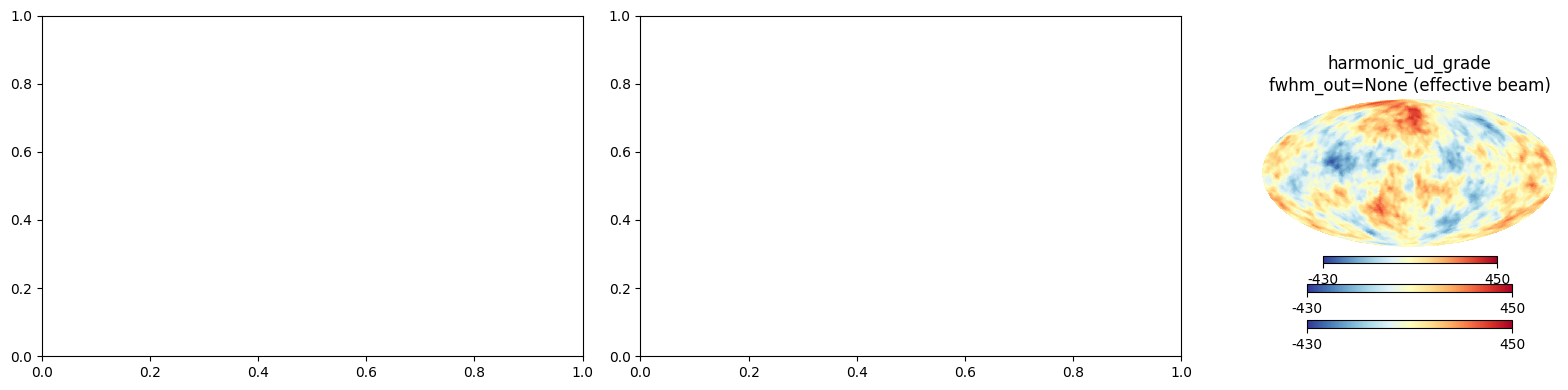

In [4]:
vmin = min(m_pixel.min(), m_harm_beam0.min(), m_harm_beam_auto.min())
vmax = max(m_pixel.max(), m_harm_beam0.max(), m_harm_beam_auto.max())
# Round to readable values
vmin = np.floor(vmin)
vmax = np.ceil(vmax)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (title, map_data) in zip(axes, [
    ("ud_grade (pixel averaging)", m_pixel),
    ("harmonic_ud_grade\nfwhm_out=0 (bandlimit only)", m_harm_beam0),
    ("harmonic_ud_grade\nfwhm_out=None (effective beam)", m_harm_beam_auto),
]):
    hp.mollview(map_data, title=title, min=vmin, max=vmax,
                cmap="RdYlBu_r", hold=True, sub=(1, 3, axes.tolist().index(ax) + 1))

plt.tight_layout()

## Power spectrum comparison

The power spectra reveal the key differences:
- `ud_grade` leaks high-$\ell$ power into low-$\ell$ modes (aliasing)
- `harmonic_ud_grade` with `fwhm_out=0` truncates cleanly but shows a sharp
  cutoff at the output bandlimit
- `harmonic_ud_grade` with `fwhm_out=None` applies the effective resolution
  beam, providing a smooth rolloff consistent with the Planck convention

In [5]:
lmax_out = 3 * nside_out - 1

cl_pixel = hp.anafast(m_pixel, lmax=lmax_out)
cl_harm_beam0 = hp.anafast(m_harm_beam0, lmax=lmax_out)
cl_harm_beam_auto = hp.anafast(m_harm_beam_auto, lmax=lmax_out)

# Input spectrum at output ell range
cl_input = cl_dust[:lmax_out + 1]

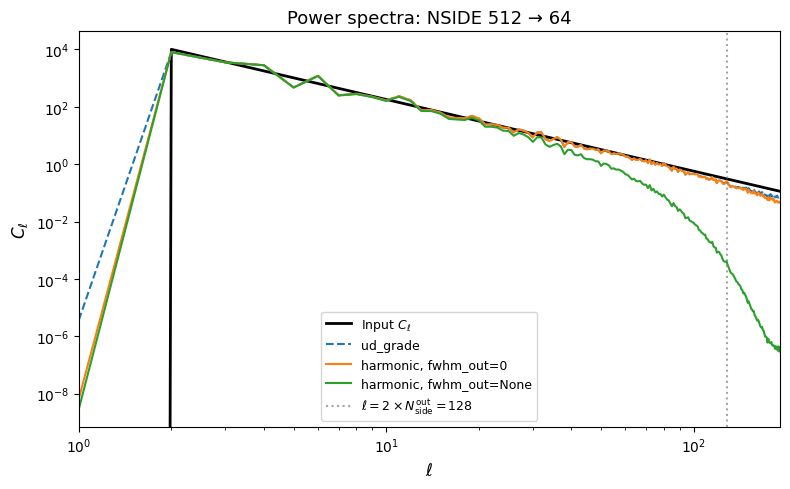

In [6]:
ell_out = np.arange(lmax_out + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ell_out[1:], cl_input[1:], "k-", lw=2, label="Input $C_\\ell$")
ax.loglog(ell_out[1:], cl_pixel[1:], "C0--", lw=1.5, label="ud_grade")
ax.loglog(ell_out[1:], cl_harm_beam0[1:], "C1-", lw=1.5, label="harmonic, fwhm_out=0")
ax.loglog(ell_out[1:], cl_harm_beam_auto[1:], "C2-", lw=1.5, label="harmonic, fwhm_out=None")

ax.axvline(2 * nside_out, color="gray", ls=":", alpha=0.7, label=f"$\\ell = 2 \\times N_{{\\rm side}}^{{\\rm out}} = {2*nside_out}$")
ax.set_xlabel("$\\ell$", fontsize=12)
ax.set_ylabel("$C_\\ell$", fontsize=12)
ax.set_title(f"Power spectra: NSIDE {nside_in} → {nside_out}", fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(1, lmax_out)
plt.tight_layout()

## Fractional difference from input

To see the effect more clearly, we plot the fractional difference of each
downgraded spectrum from the input.

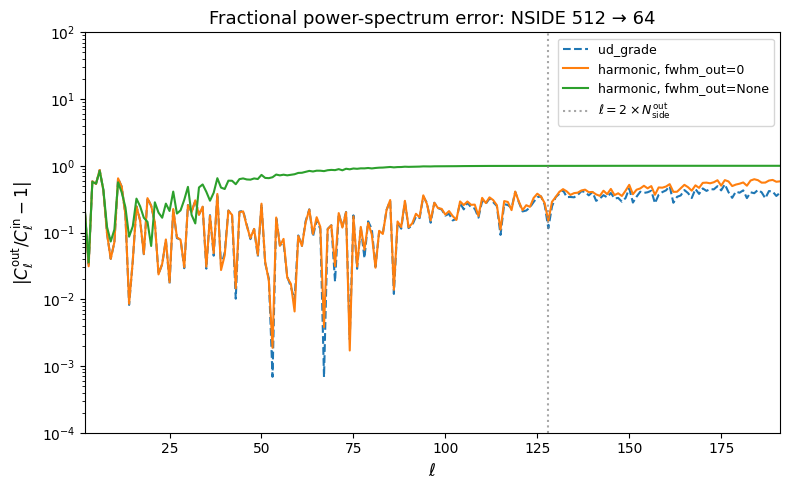

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(ell_out[2:], np.abs(cl_pixel[2:] / cl_input[2:] - 1), "C0--", lw=1.5, label="ud_grade")
ax.semilogy(ell_out[2:], np.abs(cl_harm_beam0[2:] / cl_input[2:] - 1), "C1-", lw=1.5, label="harmonic, fwhm_out=0")
ax.semilogy(ell_out[2:], np.abs(cl_harm_beam_auto[2:] / cl_input[2:] - 1), "C2-", lw=1.5, label="harmonic, fwhm_out=None")

ax.axvline(2 * nside_out, color="gray", ls=":", alpha=0.7, label=f"$\\ell = 2 \\times N_{{\\rm side}}^{{\\rm out}}$")
ax.set_xlabel("$\\ell$", fontsize=12)
ax.set_ylabel("$|C_\\ell^{\\rm out} / C_\\ell^{\\rm in} - 1|$", fontsize=12)
ax.set_title(f"Fractional power-spectrum error: NSIDE {nside_in} → {nside_out}", fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(2, lmax_out)
ax.set_ylim(1e-4, 1e2)
plt.tight_layout()

## Summary

| Method | `fwhm_out` | Behavior |
|--------|-----------|----------|
| `ud_grade` | N/A | Pixel averaging; aliases high-$\ell$ power |
| `harmonic_ud_grade` | `0` (default) | Bandlimit truncation + pixel window correction |
| `harmonic_ud_grade` | `None` | Adds effective resolution beam ($3 \times \theta_{\rm pix}$), suppresses Gibbs ringing |

For diffuse signals like Galactic dust where aliasing artifacts are most
problematic, `harmonic_ud_grade` provides a significantly cleaner downgrade
than `ud_grade`. The `fwhm_out=None` option applies a smooth beam rolloff
following the Planck 2015 X convention, while `fwhm_out=0` gives the sharpest
bandlimit.

## Try it and give feedback

    pip install --pre healpy==1.20.0b1

- API docs: <https://healpy.readthedocs.io/en/latest/generated/healpy.sphtfunc.harmonic_ud_grade.html>
- Comparison notebooks: <https://healpy.readthedocs.io/en/latest/healpy_harmonic_ud_grade_comparison.html>
- Report issues: <https://github.com/healpy/healpy/issues>